# 📊 Phase 1 — Exploratory Data Analysis (EDA)
### Sentiment Analysis on IMDB Movie Reviews

**Goal:** Understand the dataset before modelling . class balance, review length distributions, vocabulary, and common words per sentiment class.

---

## 0. Install & Import Libraries

In [1]:
# Run this cell only once to install dependencies
!pip install datasets transformers torch matplotlib seaborn wordcloud pandas scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## 1. Load the IMDB Dataset

In [6]:
# Load IMDB dataset from HuggingFace (25k train, 25k test)
dataset = load_dataset('imdb')

train_df = pd.DataFrame(dataset['train'])
test_df  = pd.DataFrame(dataset['test'])

# Map labels: 0 = Negative, 1 = Positive
label_map = {0: 'Negative', 1: 'Positive'}
train_df['sentiment'] = train_df['label'].map(label_map)
test_df['sentiment']  = test_df['label'].map(label_map)

print(f'Train set: {len(train_df):,} reviews')
print(f'Test set:  {len(test_df):,} reviews')
train_df.head(5)

Train set: 25,000 reviews
Test set:  25,000 reviews


,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,Negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,Negative
2,If only to avoid making this type of film in t...,0,Negative
3,This film was probably inspired by Godard's Ma...,0,Negative
4,"Oh, brother...after hearing about this ridicul...",0,Negative


---
## 2. Class Distribution

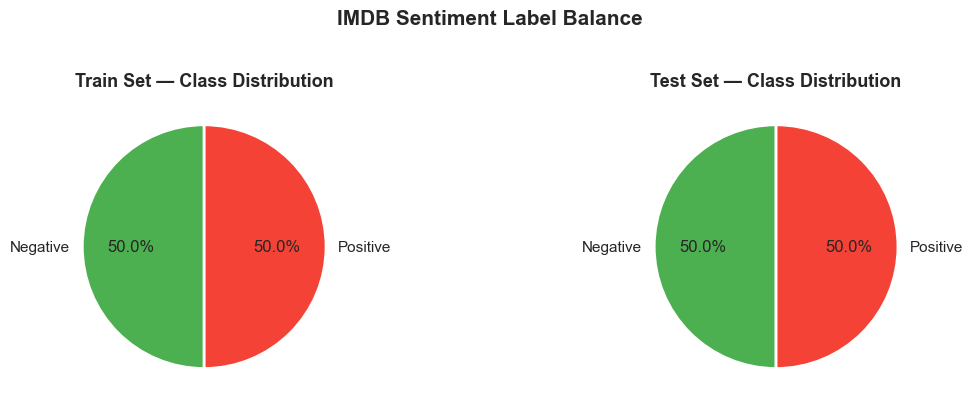

📌 Dataset is perfectly balanced — no class weighting needed.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes, [train_df, test_df], ['Train Set', 'Test Set']):
    counts = df['sentiment'].value_counts()
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    ax.set_title(f'{title} — Class Distribution', fontsize=13, fontweight='bold')

plt.suptitle('IMDB Sentiment Label Balance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('📌 Dataset is perfectly balanced — no class weighting needed.')

---
## 3. Review Length Analysis

In [9]:
# Compute word count and character count
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))
train_df['char_count'] = train_df['text'].apply(len)

print('=== Word Count Statistics ===')
print(train_df.groupby('sentiment')['word_count'].describe().round(1))

=== Word Count Statistics ===
             count   mean    std   min    25%    50%    75%     max
sentiment                                                          
Negative   12500.0  230.9  166.7  10.0  128.0  174.0  278.0  1522.0
Positive   12500.0  236.7  180.5  12.0  125.0  174.0  291.0  2470.0


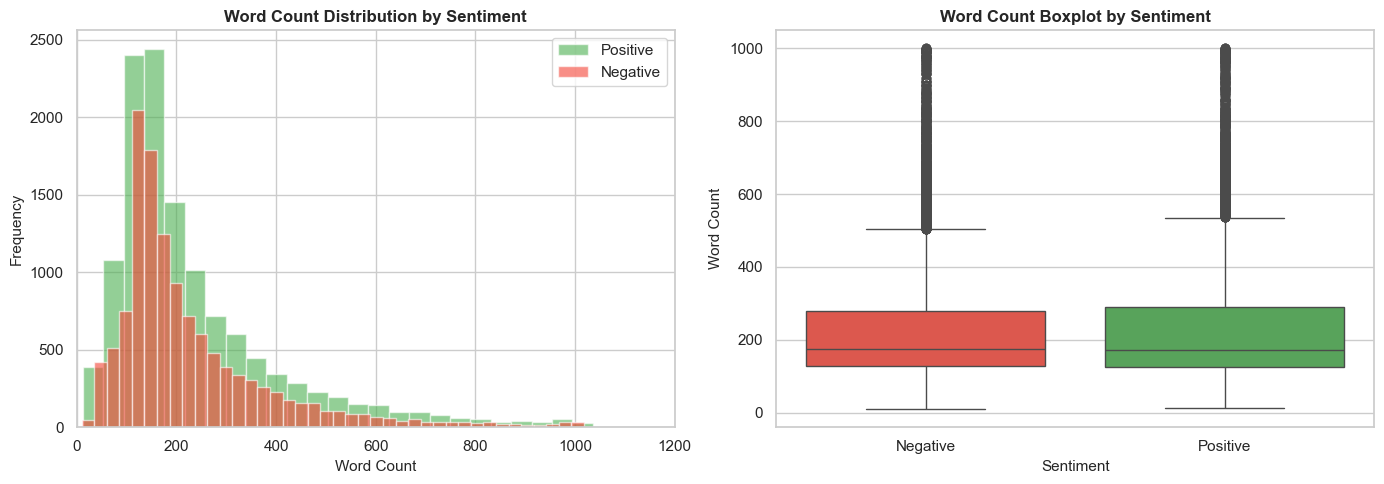

📌 Median word count: 174 words
📌 95th percentile:   598 words  →  use this as max_len for padding


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution
for sentiment, color in zip(['Positive', 'Negative'], ['#4CAF50', '#F44336']):
    subset = train_df[train_df['sentiment'] == sentiment]['word_count']
    axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=sentiment, edgecolor='white')
axes[0].set_xlabel('Word Count', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Word Count Distribution by Sentiment', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 1200)

# Boxplot
sns.boxplot(
    data=train_df[train_df['word_count'] < 1000],
    x='sentiment', y='word_count',
    palette={'Positive': '#4CAF50', 'Negative': '#F44336'},
    ax=axes[1]
)
axes[1].set_title('Word Count Boxplot by Sentiment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment', fontsize=11)
axes[1].set_ylabel('Word Count', fontsize=11)

plt.tight_layout()
plt.savefig('review_length_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

median_wc = train_df['word_count'].median()
p95_wc    = int(train_df['word_count'].quantile(0.95))
print(f'📌 Median word count: {median_wc:.0f} words')
print(f'📌 95th percentile:   {p95_wc} words  →  use this as max_len for padding')

---
## 4. Text Cleaning Helper

In [12]:
def clean_text(text: str) -> str:
    """Remove HTML tags, special characters, and lowercase."""
    text = re.sub(r'<[^>]+>', ' ', text)      # strip HTML (IMDB has <br /> tags)
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # keep only letters
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)           # collapse whitespace
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)

# Quick sanity check
print('Before:', train_df['text'].iloc[0][:200])
print()
print('After: ', train_df['clean_text'].iloc[0][:200])

Before: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev

After:  i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by us customs if it ever tried 


---
## 5. Word Frequency Analysis

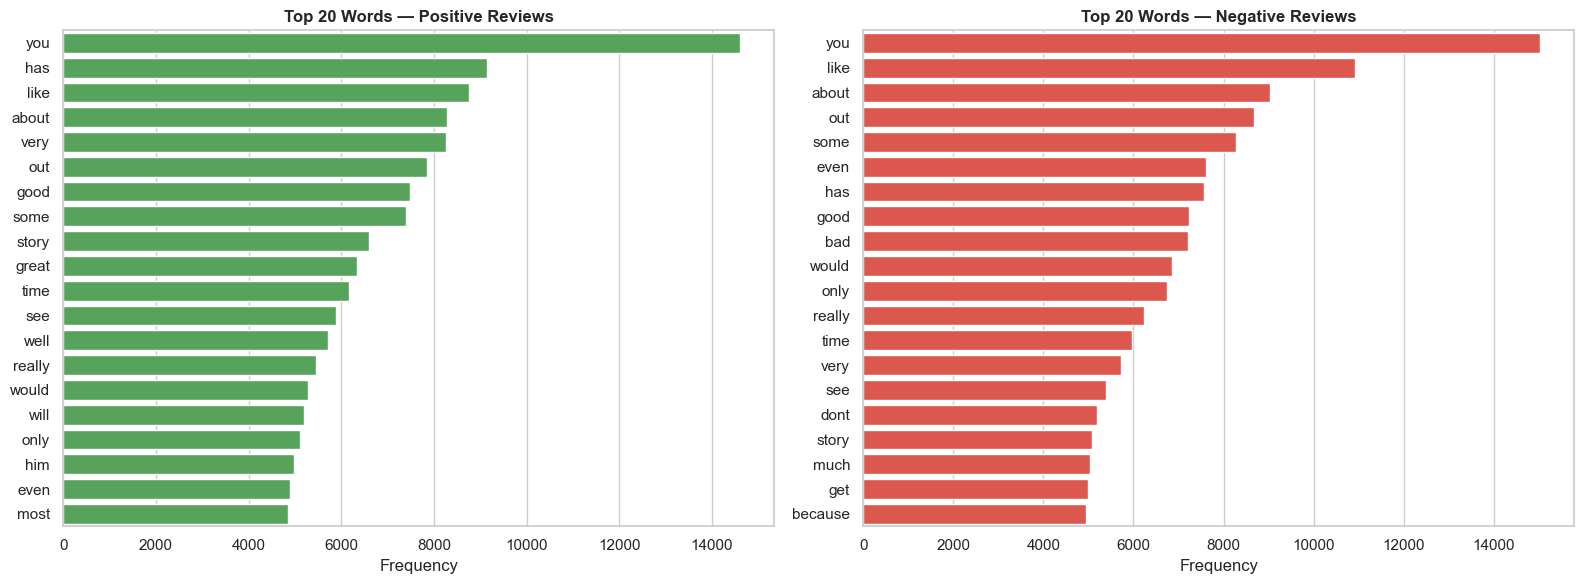

In [13]:
STOPWORDS = {
    'the','a','an','and','is','it','in','of','to','was','that','this',
    'i','for','with','on','as','he','she','are','but','film','movie',
    'at','by','not','have','be','they','his','her','one','from','or',
    'all','so','if','there','what','which','who','were','do','had',
    'when','more','its','been','also','than','their','we','can','just'
}

def get_top_words(df_subset, n=20):
    all_words = ' '.join(df_subset['clean_text']).split()
    filtered  = [w for w in all_words if w not in STOPWORDS and len(w) > 2]
    return Counter(filtered).most_common(n)

pos_words = get_top_words(train_df[train_df['sentiment'] == 'Positive'])
neg_words = get_top_words(train_df[train_df['sentiment'] == 'Negative'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, words, color, label in zip(
    axes,
    [pos_words, neg_words],
    ['#4CAF50', '#F44336'],
    ['Positive Reviews', 'Negative Reviews']
):
    words_df = pd.DataFrame(words, columns=['word', 'count'])
    sns.barplot(data=words_df, y='word', x='count', color=color, ax=ax)
    ax.set_title(f'Top 20 Words — {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('top_words.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 6. Word Clouds

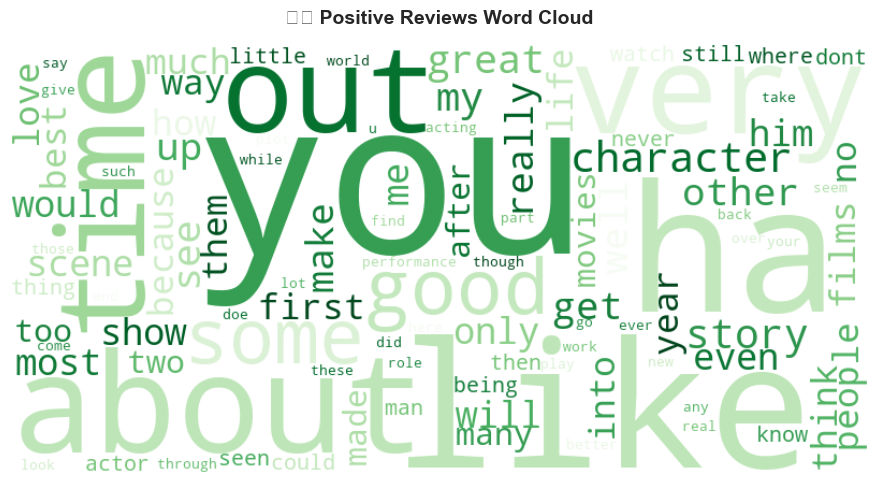

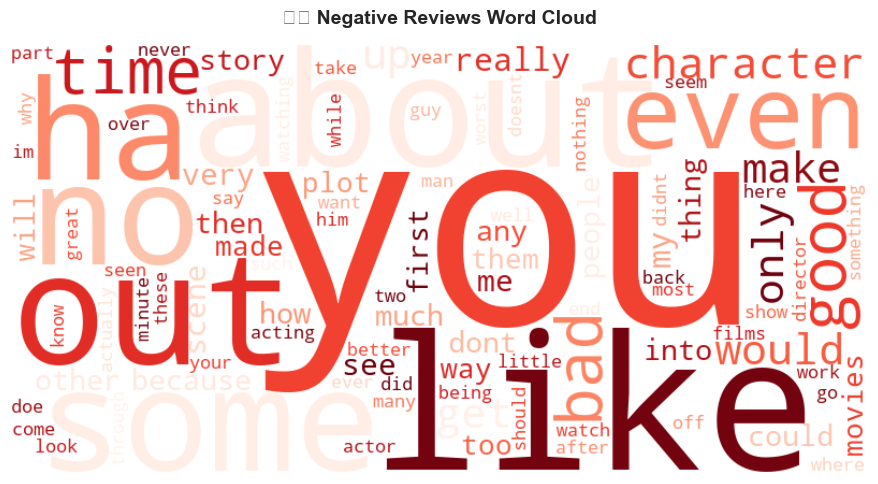

In [14]:
def make_wordcloud(text_series, stopwords, colormap, title):
    text = ' '.join(text_series)
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        stopwords=stopwords,
        colormap=colormap,
        max_words=100,
        collocations=False
    ).generate(text)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ","_")}.png', bbox_inches='tight', dpi=150)
    plt.show()

make_wordcloud(
    train_df[train_df['sentiment'] == 'Positive']['clean_text'],
    STOPWORDS, 'Greens', '☀️ Positive Reviews Word Cloud'
)

make_wordcloud(
    train_df[train_df['sentiment'] == 'Negative']['clean_text'],
    STOPWORDS, 'Reds', '🌧️ Negative Reviews Word Cloud'
)

---
## 7. Save Cleaned Data

In [15]:
train_df[['clean_text', 'label', 'sentiment']].to_csv('train_clean.csv', index=False)
test_df[['clean_text', 'label', 'sentiment']].to_csv('test_clean.csv', index=False)

print('✅ Saved train_clean.csv and test_clean.csv')
print(f'   Train: {len(train_df):,} rows')
print(f'   Test:  {len(test_df):,} rows')

✅ Saved train_clean.csv and test_clean.csv
   Train: 25,000 rows
   Test:  25,000 rows


---
## 8. EDA Summary

| Finding | Implication |
|---------|-------------|
| Perfectly balanced classes (50/50) | No class weighting or resampling needed |
| Median review ~230 words, 95th percentile ~700 words | Use `max_len=512` for LSTM padding |
| HTML tags (`<br />`) present | Text cleaning step is essential |
| Positive reviews: words like *great, best, love* | Lexicon aligns with sentiment |
| Negative reviews: words like *bad, worst, waste* | Clear signal for the model |

➡️ **Next:** `02_lstm_model.ipynb` — build and train the Bidirectional LSTM